(sec:modello-uniforme-continuo)=
# Il modello uniforme continuo

Dati $a, b \in \mathbb R$, con $a < b$, definiamo $Y = a + X (b-a)$, dove $X$
è la variabile aleatoria introdotta nel
{numref}`sec:dal-discreto-al-continuo`. Si verifica facilmente che $Y$ è una
variabile aleatoria avente come supporto $D_Y = [a, b]$, dunque una variabile
aleatoria continua. Se si considera poi un generico $y \in (a, b)$, si ha

\begin{align}
F_Y(y) &= \mathbb P(Y \leq y) = \mathbb P(a + X (b-a) \leq y) \\
       &= \mathbb P \left( X \leq \frac{y - a}{b - a} \right)
        = \frac{y - a}{b - a} \enspace,
\end{align}

mentre $\forall y < a \; \mathbb P(Y \leq y) = 0$ e
$\forall y > b \; \mathbb P(Y \leq y) = 1$, e dunque riunendo i vari casi si
ottiene

```{math}
F_Y(y) =  \frac{y - a}{b - a} \; \mathrm I_{[a, b]}(y)
          + \mathrm I_{(b + \infty)}(y) \enspace.
```

Analogamente, per $y \in (a, b)$

```{math}
f_Y(y) = F_Y'(y) = \frac{1}{b - a} \enspace.
```

D'altra parte, quando $y < a$ o $y > b$ ci si trova al di fuori del dominio
della variabile aleatoria, pertanto $f_Y(y) = 0$. Riassumendo, la densità di
$Y$ è tale che

```{math}
f_Y(y) = \frac{1}{b - a} \; \mathrm I_{[a, b]}(y) \enspace.
```

Per ogni $a < b$ abbiamo quindi definito una variabile aleatoria
continua la cui densità è costante nel corrispondente intervallo $[a, b]$.
Coerentemente con il {numref}`sec:dal-discreto-al-continuo`, ci riferiremo
a essa come alla _distribuzione uniforme continua_ sull'intervallo $[a, b]$.

````{prf:definition} La distribuzione uniforme continua
:label: def:uniform-continuous
Dati $a, b \in \mathbb R$ con $a < b$, la _distribuzione uniforme continua_
su $[a, b]$ è definita dalla densità

```{math}
f(x) =  \frac{1}{b - a} \; \mathrm I_{[a, b]}(x) \enspace,
```

o in modo equivalente dalla ripartizione

```{math}
F(x) =  \frac{y - a}{b - a} \; \mathrm I_{[a, b]}(x)
          + \mathrm I_{(b + \infty)}(x) \enspace.
```

Indicheremo il fatto che una variabile aleatoria $X$ segue una distribuzione
uniforme continua sull'intervallo $[a, b]$ utilizzando la notazione
$X \sim \mathrm U([a, b])$, con ovvie estensioni per il caso di intervalli
non chiusi. Per brevità, diremo a volte che $X$ è una variabile aleatoria
uniforme continua su $[a, b]$.
````

```{margin}
Ho scelto questo esempio per sottolineare che non tutte le distribuzioni
sono definite su supporti che contengono solo numeri non negativi.
```
La {numref}`fig:uniform-continuous` mostra il grafico delle funzioni di
densità e di ripartizione per la distribuzione uniforme continua su $[-1, 1]$.

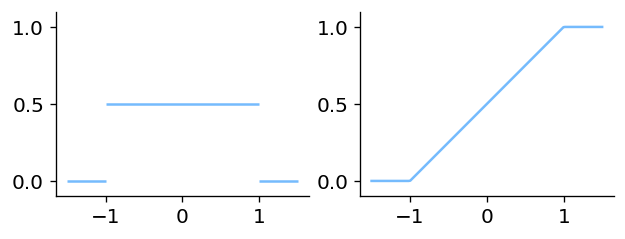

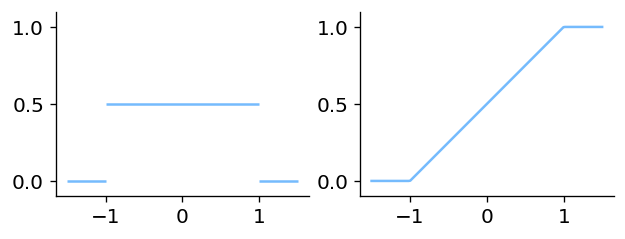

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from myst_nb import glue

def uniform_pdf(a, b, x):
    return np.where((a <= x) & (x <= b),  1 / (b - a), 0)

def uniform_cdf(a, b, x):
    return np.where((a <= x) & (x <= b), (x - a) / (b - a),
                    np.where(x < a, 0, 1))

fig, ax = plt.subplots(1, 2, figsize=[6, 2])
x = np.linspace(-1.5, 1.5, 150)
y_pdf = uniform_pdf(-1, 1, x)
y_cdf = uniform_cdf(-1, 1, x)

ax[0].hlines([0, 0.5, 0], [-1.5, -1, 1], [-1, 1, 1.5])
ax[1].plot(x, y_cdf)

for a in ax:
  a.spines.right.set_visible(False)
  a.spines.top.set_visible(False)
  a.set_yticks([0, 0.5, 1])
  a.set_ylim(-0.1, 1.1)

fig.show()


glue("uniform-continuous", fig, display=True)

```{glue:figure} uniform-continuous
---
name: fig:uniform-continuous
---
I grafici della funzione di densità (a sinistra) e della funzione di
ripartizione (a destra) della distribuzione uniforme continua sull'intervallo
$[-1, 1]$.
```

Va notato come la distribuzione derivata nel
{numref}`sec:dal-discreto-al-continuo` rappresenti la distribuzione uniforme
continua per il caso $a=0$ e $b=1$, e come in generale il procedimento seguito
per ottenere la distribuzione uniforme continua non porta a un risultato
diverso nel caso in cui il supporto da cui si parte sia un intervallo aperto o
semiaperto. Per brevità, uniamo quindi tutte le distribuzioni uniformi
continue su un intervallo nella famiglia definita di seguito.

```{margin}
Nonostante sia possibile definire una distribuzione uniforme su un insieme
continuo che non sia un intervallo, per brevità si utilizza la dicitura
_uniforme continua_ per riferirsi alle sole distribuzioni che hanno un
intervallo come supporto.
```
````{prf:definition} La famiglia uniforme continua
:label: def:continuous-uniform-family
La _famiglia uniforme continua_ comprende tutte le definizioni uniformi
continue definite su un intervallo in $\mathbb R$, indipdententemente dalla
particolare forma di questo intervallo.
````

## Media e varianza

Media, varianza e deviazione standard di una generica distribuzione
uniforme continua si ottengono facilmente a partire dalle definizioni
corrispondenti.

````{prf:lemma}
Dati $a, b \in \mathbb R$ con $a < b$, sia $X \sim \mathrm U([a, b])$. Si ha

```{math}
:label: eq:uniform-continuous
\mathbb E(X) = \frac{a + b}{2}
\quad \text{e} \quad
\mathrm{Var}(X) = \frac{(b - a)^2}{12} \enspace.
```
```{prf:proof}
Il valore atteso si calcola sfruttando il prodotto notevole legato alla
differenza di quadrati:

\begin{align*}
\mathbb E(X) &= \int_{-\infty}^{+\infty} x f_X(x; a, b) \;\mathrm d x
              = \int_a^b \frac{x}{b - a} \;\mathrm d x \\
             &= \frac{1}{b-a} \frac{x^2}{2} \bigg|_a^b
              = \frac{b^2 - a^2}{2(b - a)} = \frac{a + b}{2} \enspace.
\end{align*}

Analogamente, la formula relativa alla differenza di cubi permette di
calcolare $\mathbb E(X^2)$:

\begin{align*}
\mathbb E(X^2) &= \int_{-\infty}^{+\infty} x^2 f_X(x; a, b) \;\mathrm d x
              = \int_a^b \frac{x^2}{b - a} \;\mathrm d x \\
             &= \frac{1}{b-a} \frac{x^3}{3} \bigg|_a^b
              = \frac{b^3 - a^3}{3(b - a)}
              = \frac{b^2 + a b + a^2}{3} \enspace,
\end{align*}

così che $\mathrm{Var}(X) = \frac{b^2 + a b + a^2}{3} -
                            \frac{b^2 - 2 a b + a^2}{4}
                          = \frac{b^2 - a^2}{12}$.
```
````

Si può notare che considerando $X \sim \mathrm U([0, 1])$ e
$Y \coloneq a + (b - a) X \sim \mathrm U([a, b])$, come indicato all'inizio di
questo paragrafo, le proprietà di valore atteso e varianza permettono di
ottenere in modo alternativo gli stessi risultati partendo da quanto ottenuto
nel {numref}`sec:dal-discreto-al-continuo` per la distribuzione uniforme
continua in $[0, 1]$: precisamente, $\mathbb E(Y) = a + (b - a) \mathbb E(X)
= a + \frac{b - a}{2} =  \frac{a + b}{2}$ e $\mathrm{Var}(Y) = (b - a)^2
\mathrm{Var}(X) = \frac{(b - a)^2)}{12}$. Inoltre sostituendo $a=0$ e $b=1$
in {eq}`eq:uniform-continuous` si ottengono la media e la varianza della
distribuzione uniforme continua in $[0, 1]$.


## Quantili

```{margin}
Per non complicare la trattazione, ho fatto qui riferimento a intervalli
chiusi, ma il ragionamento descritto vale per qualsiasi tipo di intervalli.
```
Tenuto conto del fatto che la densità di una distribuzione uniforme
continua è costante su un intervallo $I = [a, b]$ e nulla altrove,
intuitivamente il relativo quantile di livello $q \in [0, 1]$ sarà il punto di
$I$ caratterizzato dalle seguenti proprietà:
- la sua distanza da $a$ cresce linearmente rispetto a $q$,
- la sua distanza da $b$ cresce linearmente rispetto a $1-q$.

Più formalmente, $x_q$ sarà uguale alla _combinazione lineare convessa_ di
$a$ e $b$ che ha $q$ come coefficiente:

```{math}
x_q = a + q (b - a) \enspace,
```
come dimostrato qui di seguito.

````{prf:lemma}
Dati $a, b \in \mathbb R$ con $a < b$, una variabile aleatoria
$X \sim \mathrm U([a, b])$ e $q \in [0, 1]$, il quantile di livello $q$ di
$X$ è $x_q = a + q (b - a).
```{prf:proof}
La tesi è banale quando $q=0$ perché in questo caso il quantile è la più
piccola specificazione di $X$ e dunque $x_0 = a = a + 0 (b - a)$. Un
ragionamento analogo vale nel caso $q =1 $. Concentriamoci dunque sul caso
$q \in (0, 1)$ e consideraimo l'equazione $F_X(x_q) = q$, che definisce il
quantile cercato e che equivale a

\begin{equation*}
\frac{x - a}{b - a} = q \enspace.
\end{equation*}

La sua soluzione è $x_q = a + q (b - a)$.
```
````

Pertanto la mediana di una variabile aleatoria uniforme continua coincide
con la sua media, cosa peraltro implicata dal fatto che la sua densità di
probabilità è simmetrica rispetto a $\mathbb E(X)$.